# **PHASE 6 — PHÂN TÍCH KẾT QUẢ & TRỰC QUAN HÓA**

**Cell 6.1: Setup & Load history**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = 'D:/DoAnTriTueNhanTao/skin_cancer'
os.makedirs(f'{BASE}/figures', exist_ok=True)

mc_hist = pd.read_csv(f'{BASE}/results/multiclass_history.csv')
bin_hist = pd.read_csv(f'{BASE}/results/binary_history.csv')

print("Multi-class epochs:", len(mc_hist))
print("Binary epochs:     ", len(bin_hist))

best_mc = mc_hist.loc[mc_hist['balanced_acc'].idxmax()]
best_bin = bin_hist.loc[bin_hist['auc'].idxmax()]
print(f"\nBest Multi-class: epoch {int(best_mc['epoch'])}, bal_acc={best_mc['balanced_acc']:.4f}, f1={best_mc['f1_macro']:.4f}")
print(f"Best Binary:      epoch {int(best_bin['epoch'])}, auc={best_bin['auc']:.4f}, f1={best_bin['f1']:.4f}")

Multi-class epochs: 19
Binary epochs:      15

Best Multi-class: epoch 11, bal_acc=0.7819, f1=0.7505
Best Binary:      epoch 15, auc=0.9419, f1=0.8211


**Cell 6.2: Learning curves — Binary**

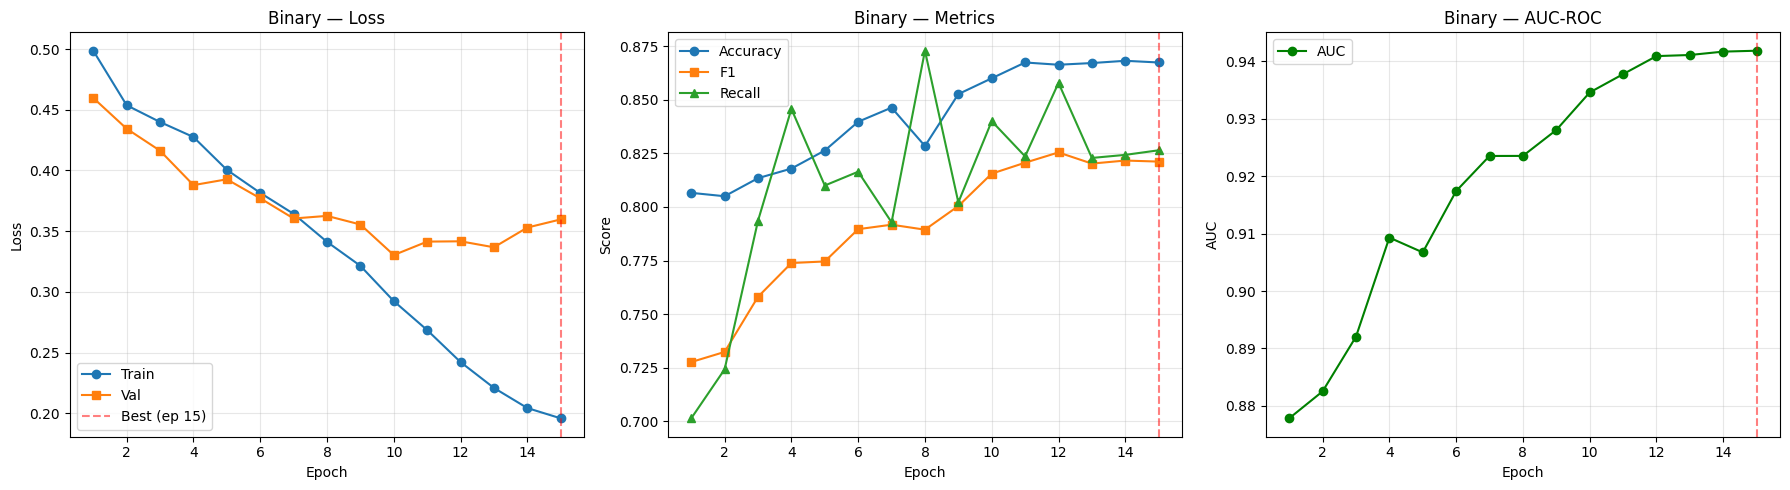

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(bin_hist['epoch'], bin_hist['train_loss'], 'o-', label='Train')
axes[0].plot(bin_hist['epoch'], bin_hist['loss'], 's-', label='Val')
axes[0].axvline(best_bin['epoch'], color='red', ls='--', alpha=0.5, label=f"Best (ep {int(best_bin['epoch'])})")
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Binary — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Acc & F1
axes[1].plot(bin_hist['epoch'], bin_hist['acc'], 'o-', label='Accuracy')
axes[1].plot(bin_hist['epoch'], bin_hist['f1'], 's-', label='F1')
axes[1].plot(bin_hist['epoch'], bin_hist['recall'], '^-', label='Recall')
axes[1].axvline(best_bin['epoch'], color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Binary — Metrics'); axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(bin_hist['epoch'], bin_hist['auc'], 'o-', color='green', label='AUC')
axes[2].axvline(best_bin['epoch'], color='red', ls='--', alpha=0.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].set_title('Binary — AUC-ROC'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/binary_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Cell 6.3: Learning curves — Multi-class**

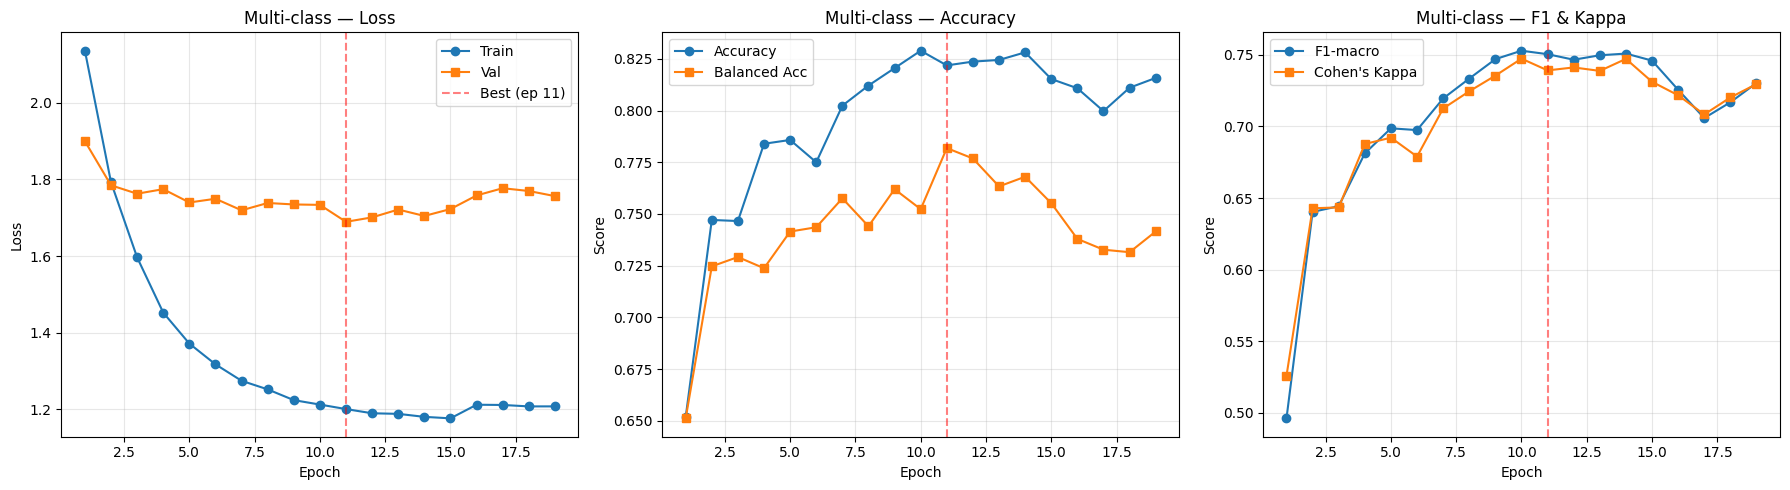

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(mc_hist['epoch'], mc_hist['train_loss'], 'o-', label='Train')
axes[0].plot(mc_hist['epoch'], mc_hist['loss'], 's-', label='Val')
axes[0].axvline(best_mc['epoch'], color='red', ls='--', alpha=0.5, label=f"Best (ep {int(best_mc['epoch'])})")
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Multi-class — Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Acc
axes[1].plot(mc_hist['epoch'], mc_hist['acc'], 'o-', label='Accuracy')
axes[1].plot(mc_hist['epoch'], mc_hist['balanced_acc'], 's-', label='Balanced Acc')
axes[1].axvline(best_mc['epoch'], color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Multi-class — Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

# F1 & Kappa
axes[2].plot(mc_hist['epoch'], mc_hist['f1_macro'], 'o-', label='F1-macro')
axes[2].plot(mc_hist['epoch'], mc_hist['kappa'], 's-', label="Cohen's Kappa")
axes[2].axvline(best_mc['epoch'], color='red', ls='--', alpha=0.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
axes[2].set_title('Multi-class — F1 & Kappa'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/multiclass_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**Cell 6.4: Per-class metrics từ predictions**

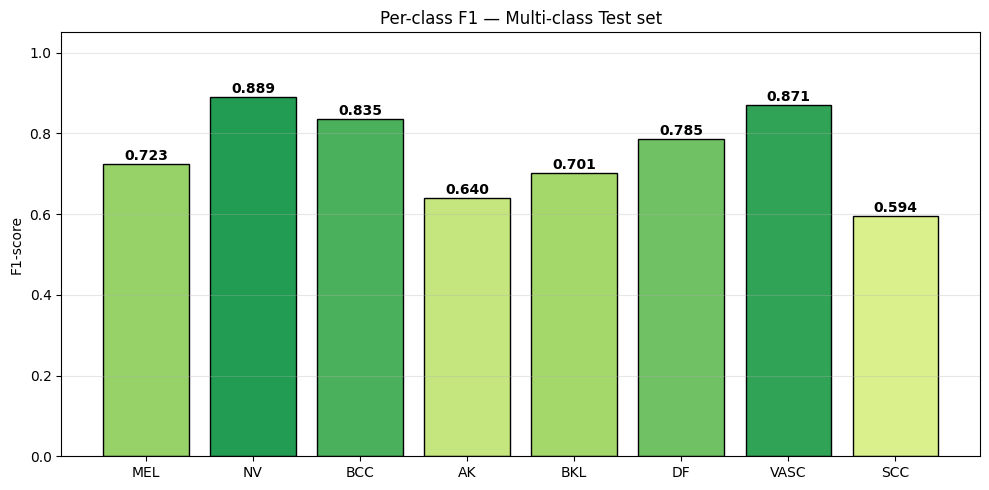


Chi tiết per-class:
  MEL   | P=0.761 | R=0.689 | F1=0.723 | n=679
  NV    | P=0.889 | R=0.890 | F1=0.889 | n=1931
  BCC   | P=0.820 | R=0.850 | F1=0.835 | n=499
  AK    | P=0.569 | R=0.731 | F1=0.640 | n=130
  BKL   | P=0.698 | R=0.705 | F1=0.701 | n=393
  DF    | P=0.721 | R=0.861 | F1=0.785 | n=36
  VASC  | P=0.787 | R=0.974 | F1=0.871 | n=38
  SCC   | P=0.642 | R=0.553 | F1=0.594 | n=94


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
mc_pred = pd.read_csv(f'{BASE}/results/multiclass_test_predictions.csv')

y_true = mc_pred['label'].values
y_pred = mc_pred['pred_label'].values

# Per-class F1
per_class_f1 = f1_score(y_true, y_pred, average=None, labels=range(8), zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(per_class_f1)
bars = ax.bar(CLASSES, per_class_f1, color=colors, edgecolor='black')
for b, v in zip(bars, per_class_f1):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 — Multi-class Test set')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/multiclass_per_class_f1.png', dpi=150)
plt.show()

print("\nChi tiết per-class:")
report = classification_report(y_true, y_pred, target_names=CLASSES,
                                output_dict=True, zero_division=0)
for cls in CLASSES:
    r = report[cls]
    print(f"  {cls:5s} | P={r['precision']:.3f} | R={r['recall']:.3f} | F1={r['f1-score']:.3f} | n={int(r['support'])}")

**Cell 6.5: So sánh Binary vs Multi-class**

In [6]:
bin_pred = pd.read_csv(f'{BASE}/results/binary_test_predictions.csv')

# Nhóm malignant từ multiclass
MALIGNANT = ['MEL', 'BCC', 'SCC', 'AK']

# Từ multi-class dự đoán → suy ra binary (nếu pred là malignant thì coi là 1)
mc_to_bin_pred = mc_pred['pred_label_name'].apply(lambda x: 1 if x in MALIGNANT else 0).values
mc_true_bin = mc_pred['label_name'].apply(lambda x: 1 if x in MALIGNANT else 0).values

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, balanced_accuracy_score)

# Multi-class suy ra binary (gộp xác suất 4 lớp malignant)
mc_malig_prob = mc_pred[[f'prob_{c}' for c in MALIGNANT]].sum(axis=1).values

comparison = pd.DataFrame({
    'Model': ['Binary (trực tiếp)', 'Multi-class → Binary'],
    'Accuracy':  [accuracy_score(bin_pred['binary_label'], bin_pred['pred_binary']),
                  accuracy_score(mc_true_bin, mc_to_bin_pred)],
    'Balanced Acc': [balanced_accuracy_score(bin_pred['binary_label'], bin_pred['pred_binary']),
                     balanced_accuracy_score(mc_true_bin, mc_to_bin_pred)],
    'Precision': [precision_score(bin_pred['binary_label'], bin_pred['pred_binary']),
                  precision_score(mc_true_bin, mc_to_bin_pred)],
    'Recall':    [recall_score(bin_pred['binary_label'], bin_pred['pred_binary']),
                  recall_score(mc_true_bin, mc_to_bin_pred)],
    'F1':        [f1_score(bin_pred['binary_label'], bin_pred['pred_binary']),
                  f1_score(mc_true_bin, mc_to_bin_pred)],
    'AUC':       [roc_auc_score(bin_pred['binary_label'], bin_pred['prob_malignant']),
                  roc_auc_score(mc_true_bin, mc_malig_prob)],
})

print(comparison.round(4).to_string(index=False))
comparison.to_csv(f'{BASE}/results/model_comparison.csv', index=False)
print(f"\n✓ Lưu: {BASE}/results/model_comparison.csv")

               Model  Accuracy  Balanced Acc  Precision  Recall     F1    AUC
  Binary (trực tiếp)    0.8626        0.8553     0.8056  0.8274 0.8163 0.9366
Multi-class → Binary    0.8842        0.8740     0.8486  0.8352 0.8418 0.9283

✓ Lưu: D:/DoAnTriTueNhanTao/skin_cancer/results/model_comparison.csv
